In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/ML_Projects/Yeast_Protein_Clustering"

In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

In [42]:
import pandas as pd

df = pd.read_csv(f"{PROJECT_PATH}/yeast_data.csv")

In [43]:
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,class
0,0.353677,0.021425,0.092096,0.123528,0.021742,0.025167,0.075151,0.174236,NUC
1,0.248558,0.303936,0.277090,0.309470,0.066889,0.024401,0.056978,0.488509,CYT
2,0.415959,0.652047,0.364459,0.102175,0.229521,0.001469,0.093070,0.545098,CYT
3,0.159968,0.141061,0.394180,0.161639,0.065338,0.016994,0.335486,0.056403,NUC
4,0.550283,0.298777,0.239343,0.193423,0.043884,0.058044,0.218051,0.318824,MIT


In [44]:
print(df.shape)

(1484, 9)


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     1484 non-null   float64
 1   gvh     1484 non-null   float64
 2   alm     1484 non-null   float64
 3   mit     1484 non-null   float64
 4   erl     1484 non-null   float64
 5   pox     1484 non-null   float64
 6   vac     1484 non-null   float64
 7   nuc     1484 non-null   float64
 8   class   1484 non-null   object 
dtypes: float64(8), object(1)
memory usage: 104.5+ KB


In [46]:
df.describe()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.287838,0.288121,0.299669,0.193202,0.097594,0.046281,0.092095,0.371117
std,0.156775,0.159747,0.135447,0.117418,0.088278,0.043337,0.084825,0.161288
min,0.005368,0.006476,0.023489,0.010093,0.000179,0.000005,0.000108,0.014569
25%,0.168723,0.163909,0.197772,0.102704,0.029519,0.013625,0.027648,0.253865
50%,0.266995,0.264100,0.288467,0.172478,0.070474,0.034420,0.066102,0.350727
75%,0.390514,0.394091,0.387197,0.258366,0.142804,0.066225,0.133224,0.482108
max,0.813342,0.819733,0.770321,0.648309,0.565470,0.296635,0.475324,0.918417


In [47]:
df.isnull().sum()

,0
mcg,0
gvh,0
alm,0
mit,0
erl,0
pox,0
vac,0
nuc,0
class,0


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
print(df.columns)

Index(['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc', 'class'], dtype='object')


In [51]:
df["class"].value_counts()

,count
class,
CYT,694
NUC,468
MIT,216
ME3,56
ME2,18
EXC,15
POX,7
ME1,6
VAC,3


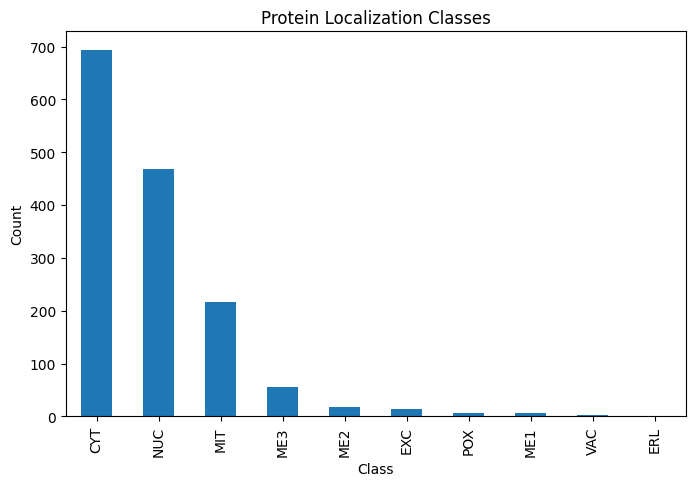

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["class"].value_counts().plot(kind="bar")

plt.title("Protein Localization Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [54]:
plt.savefig(f"{PROJECT_PATH}/class_distribution.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [55]:
X = df.drop("class", axis=1)

X.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
0,0.353677,0.021425,0.092096,0.123528,0.021742,0.025167,0.075151,0.174236
1,0.248558,0.303936,0.277090,0.309470,0.066889,0.024401,0.056978,0.488509
2,0.415959,0.652047,0.364459,0.102175,0.229521,0.001469,0.093070,0.545098
3,0.159968,0.141061,0.394180,0.161639,0.065338,0.016994,0.335486,0.056403
4,0.550283,0.298777,0.239343,0.193423,0.043884,0.058044,0.218051,0.318824


In [56]:
print(X.shape)

(1484, 8)


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [58]:
X_scaled[:5]

array([[ 4.20097331e-01, -1.67005368e+00, -1.53302455e+00,
        -5.93578130e-01, -8.59530943e-01, -4.87358245e-01,
        -1.99812243e-01, -1.22109261e+00],
       [-2.50636647e-01,  9.90378341e-02, -1.66755557e-01,
         9.90542417e-01, -3.47943218e-01, -5.05049081e-01,
        -4.14131708e-01,  7.28086680e-01],
       [ 8.17505075e-01,  2.27890981e+00,  4.78507838e-01,
        -7.75494797e-01,  1.49494876e+00, -1.03439485e+00,
         1.15066646e-02,  1.07906196e+00],
       [-8.15909177e-01, -9.20886211e-01,  6.98006578e-01,
        -2.68897979e-01, -3.65519978e-01, -6.76032256e-01,
         2.87030809e+00, -1.95191521e+00],
       [ 1.67459100e+00,  6.67279896e-02, -4.45536556e-01,
         1.88489734e-03, -6.08631555e-01,  2.71533732e-01,
         1.48540480e+00, -3.24326149e-01]])

In [59]:
import joblib

joblib.dump(
    scaler,
    f"{PROJECT_PATH}/scaler.pkl"
)

['/content/drive/MyDrive/Colab Notebooks/ML_Projects/Yeast_Protein_Clustering/scaler.pkl']

In [60]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2, 11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

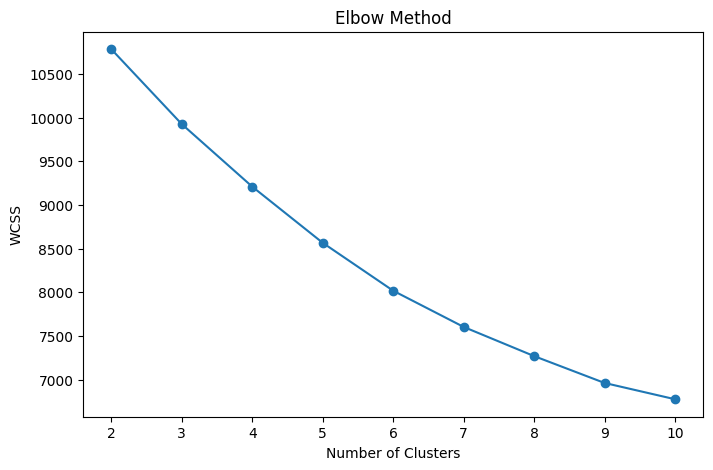

In [61]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [62]:
plt.savefig(
    f"{PROJECT_PATH}/elbow_plot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"k = {k} --> Silhouette Score = {score:.4f}")

k = 2 --> Silhouette Score = 0.0928
k = 3 --> Silhouette Score = 0.1131
k = 4 --> Silhouette Score = 0.1142
k = 5 --> Silhouette Score = 0.1059
k = 6 --> Silhouette Score = 0.1105
k = 7 --> Silhouette Score = 0.1065
k = 8 --> Silhouette Score = 0.1054
k = 9 --> Silhouette Score = 0.1056
k = 10 --> Silhouette Score = 0.1071


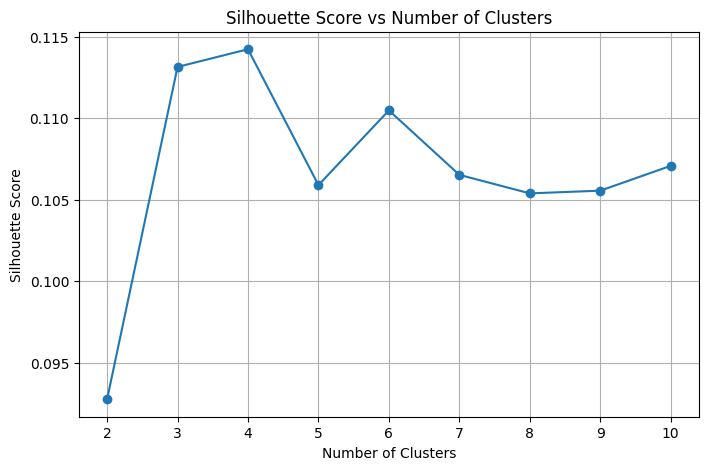

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [65]:
plt.savefig(
    f"{PROJECT_PATH}/silhouette_score.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [66]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,class,Cluster
0,0.353677,0.021425,0.092096,0.123528,0.021742,0.025167,0.075151,0.174236,NUC,2
1,0.248558,0.303936,0.277090,0.309470,0.066889,0.024401,0.056978,0.488509,CYT,0
2,0.415959,0.652047,0.364459,0.102175,0.229521,0.001469,0.093070,0.545098,CYT,3
3,0.159968,0.141061,0.394180,0.161639,0.065338,0.016994,0.335486,0.056403,NUC,2
4,0.550283,0.298777,0.239343,0.193423,0.043884,0.058044,0.218051,0.318824,MIT,0


In [67]:
import joblib

joblib.dump(
    kmeans,
    f"{PROJECT_PATH}/kmeans_model.pkl"
)

['/content/drive/MyDrive/Colab Notebooks/ML_Projects/Yeast_Protein_Clustering/kmeans_model.pkl']

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

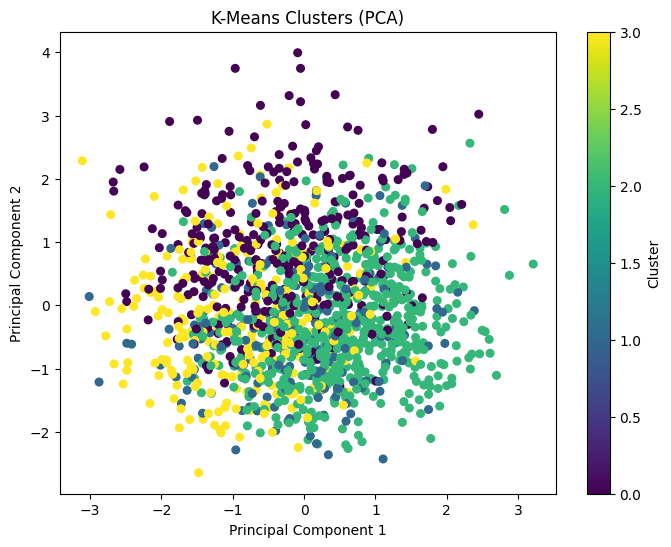

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=30
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [70]:
plt.savefig(
    f"{PROJECT_PATH}/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [71]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

agg_clusters = agg.fit_predict(X_scaled)

df["Agglomerative_Cluster"] = agg_clusters

In [72]:
pd.crosstab(df["class"], df["Cluster"])

Cluster,0,1,2,3
class,,,,
CYT,164,109,299,122
ERL,0,0,0,1
EXC,1,2,10,2
ME1,4,1,0,1
ME2,4,3,9,2
ME3,18,6,16,16
MIT,50,29,91,46
NUC,100,51,229,88
POX,3,3,1,0


In [73]:
df.to_csv(
    f"{PROJECT_PATH}/clustered_yeast.csv",
    index=False
)

In [74]:
joblib.dump(
    scaler,
    f"{PROJECT_PATH}/scaler.pkl"
)

['/content/drive/MyDrive/Colab Notebooks/ML_Projects/Yeast_Protein_Clustering/scaler.pkl']

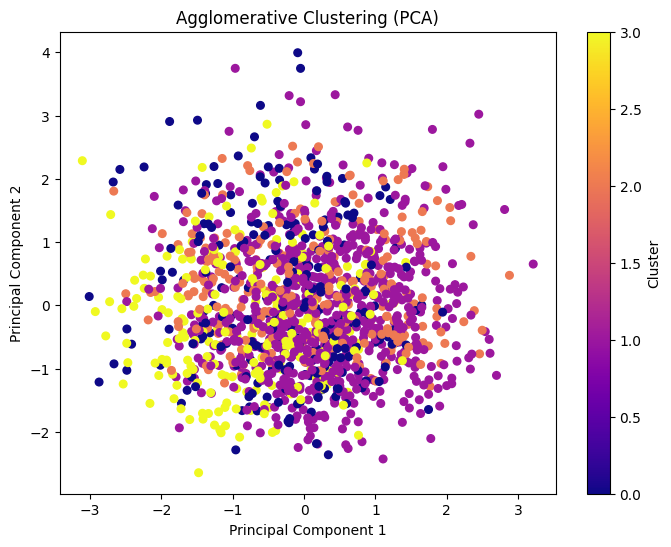

In [75]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_clusters,
    cmap="plasma",
    s=30
)

plt.title("Agglomerative Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [76]:
plt.savefig(
    f"{PROJECT_PATH}/agglomerative_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [77]:
print("K-Means Silhouette Score:",
      silhouette_score(X_scaled, clusters))

print("Agglomerative Silhouette Score:",
      silhouette_score(X_scaled, agg_clusters))

K-Means Silhouette Score: 0.11422489839186188
Agglomerative Silhouette Score: 0.07075533335366853


In [78]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,344
1,204
2,657
3,279


In [79]:
df["Agglomerative_Cluster"].value_counts().sort_index()

,count
Agglomerative_Cluster,
0,247
1,737
2,276
3,224


In [80]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

cluster_centers

,mcg,gvh,alm,mit,erl,pox,vac,nuc
0,0.075860,0.484397,-0.200550,1.189506,-0.286809,-0.270951,0.280983,0.124622
1,0.084144,-0.104493,-0.002321,-0.005260,-0.288772,1.868625,0.004840,-0.023304
2,-0.038303,-0.241818,0.157097,-0.520955,-0.453598,-0.378712,-0.110620,-0.119265
3,-0.064860,0.048596,-0.120967,-0.236021,1.632923,-0.140425,-0.089491,0.144233


In [81]:
cluster_centers.to_csv(
    f"{PROJECT_PATH}/cluster_centers.csv",
    index=False
)

In [82]:
df.to_csv(
    f"{PROJECT_PATH}/final_clustered_data.csv",
    index=False
)